# Cross-subject classification

Window-level protocol only. This notebook evaluates:
- 1D Feature CNN (primary)
- EEGNet (raw)
- EEGNet (bandpower)
- GAT
- CNN-GAT

All models use grouped validation splits (recording-wise groups) to reduce leakage.

## Imports and Setup


In [22]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, sosfiltfilt, welch
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {DEVICE}")

CLASSES = ["rest", "motor", "math", "memory"]
DATA_DIR = "Preprocessed data"
BP_DIR = "Bandpower data"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

PyTorch device: cpu


## Load Cross Windowed Data

Load preprocessed train/test window arrays and build recording-wise groups for leakage-safe validation splits.


In [23]:
def load_dataset(name, base_dir=DATA_DIR):
    return np.load(os.path.join(base_dir, f"{name}.npy"))


def make_window_groups(n_windows, n_recordings):
    wpr = n_windows // n_recordings
    groups = np.repeat(np.arange(n_recordings), wpr)
    if len(groups) < n_windows:
        groups = np.concatenate([groups, np.arange(n_windows - len(groups)) + n_recordings])
    return groups[:n_windows]


def grouped_split_indices(y, groups, test_size=0.2, seed=42):
    try:
        n_splits = max(3, min(8, int(round(1.0 / max(test_size, 1e-6)))))
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        tr, va = next(sgkf.split(np.zeros(len(y)), y, groups))
        return tr, va
    except Exception:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        tr, va = next(gss.split(np.zeros(len(y)), y, groups))
        return tr, va


X_cross_train_w = load_dataset("X_cross_train_w")
y_cross_train_w = load_dataset("y_cross_train_w")
X_cross_test1_w = load_dataset("X_cross_test1_w")
y_cross_test1_w = load_dataset("y_cross_test1_w")
X_cross_test2_w = load_dataset("X_cross_test2_w")
y_cross_test2_w = load_dataset("y_cross_test2_w")
X_cross_test3_w = load_dataset("X_cross_test3_w")
y_cross_test3_w = load_dataset("y_cross_test3_w")

y_cross_train_rec = load_dataset("y_cross_train")
cross_train_groups = make_window_groups(len(y_cross_train_w), len(y_cross_train_rec))

print("Cross train:", X_cross_train_w.shape, y_cross_train_w.shape)
print("Cross test1:", X_cross_test1_w.shape, y_cross_test1_w.shape)
print("Cross test2:", X_cross_test2_w.shape, y_cross_test2_w.shape)
print("Cross test3:", X_cross_test3_w.shape, y_cross_test3_w.shape)
print("Train groups:", len(np.unique(cross_train_groups)))

Cross train: (1024, 248, 500) (1024,)
Cross test1: (128, 248, 500) (128,)
Cross test2: (128, 248, 500) (128,)
Cross test3: (128, 248, 500) (128,)
Train groups: 64


## Shared Helpers

Utilities for plotting, feature preparation, and model components used across sections.


In [24]:
def plot_cm_and_report(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))


def temporal_attention_1d(x):
    weights = layers.Dense(1, activation="tanh")(x)
    weights = layers.Softmax(axis=1)(weights)
    return layers.multiply([x, weights])


def squeeze_excite_1d(x, ratio=8):
    filters = int(x.shape[-1])
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(max(1, filters // ratio), activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    se = layers.Reshape((1, filters))(se)
    return layers.multiply([x, se])


def build_1d_cnn(input_shape, num_classes, dropout_rate=0.3, initial_filters=16, attention=False):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(initial_filters, kernel_size=7, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = temporal_attention_1d(x)
        x = squeeze_excite_1d(x)

    x = layers.Conv1D(initial_filters * 2, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = temporal_attention_1d(x)
        x = squeeze_excite_1d(x)

    x = layers.Conv1D(initial_filters * 4, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = temporal_attention_1d(x)
        x = squeeze_excite_1d(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="brain_state_1dcnn")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def expand_bandpower_for_1d(band_power, time_steps):
    expanded = np.repeat(band_power[:, np.newaxis, :, :], repeats=time_steps, axis=1)
    return expanded.reshape(band_power.shape[0], time_steps, -1)


def prepare_1d_feature_input(X, bp):
    X_1d = np.transpose(X, (0, 2, 1)).astype("float32")
    X_1d_combined = np.concatenate([X_1d, expand_bandpower_for_1d(bp, X_1d.shape[1])], axis=-1)
    return X_1d_combined.astype("float32")

## Primary Model — 1D Feature CNN

Train/evaluate the primary cross-subject model on window-level labels for `test1`, `test2`, and `test3`.


Epoch 1/40
51/51 - 3s - 50ms/step - accuracy: 0.5110 - loss: 1.1277 - val_accuracy: 0.5577 - val_loss: 1.0901 - learning_rate: 0.0010
Epoch 2/40
51/51 - 1s - 23ms/step - accuracy: 0.7414 - loss: 0.6125 - val_accuracy: 0.8029 - val_loss: 0.6126 - learning_rate: 0.0010
Epoch 3/40
51/51 - 1s - 23ms/step - accuracy: 0.8738 - loss: 0.3531 - val_accuracy: 0.8654 - val_loss: 0.4581 - learning_rate: 0.0010
Epoch 4/40
51/51 - 1s - 23ms/step - accuracy: 0.9326 - loss: 0.1963 - val_accuracy: 0.8365 - val_loss: 0.5022 - learning_rate: 0.0010
Epoch 5/40
51/51 - 1s - 23ms/step - accuracy: 0.9571 - loss: 0.1325 - val_accuracy: 0.8221 - val_loss: 0.4245 - learning_rate: 0.0010
Epoch 6/40
51/51 - 1s - 23ms/step - accuracy: 0.9743 - loss: 0.0955 - val_accuracy: 0.8077 - val_loss: 0.5494 - learning_rate: 0.0010
Epoch 7/40
51/51 - 1s - 22ms/step - accuracy: 0.9743 - loss: 0.0899 - val_accuracy: 0.7644 - val_loss: 0.5576 - learning_rate: 0.0010
Epoch 8/40
51/51 - 1s - 23ms/step - accuracy: 0.9657 - loss: 0

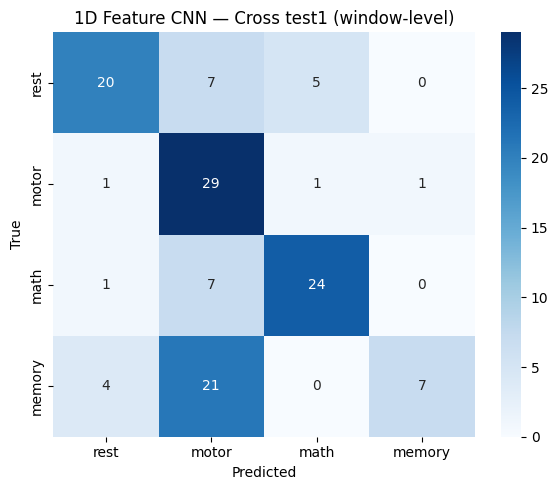

              precision    recall  f1-score   support

        rest       0.77      0.62      0.69        32
       motor       0.45      0.91      0.60        32
        math       0.80      0.75      0.77        32
      memory       0.88      0.22      0.35        32

    accuracy                           0.62       128
   macro avg       0.72      0.62      0.60       128
weighted avg       0.72      0.62      0.60       128

1D Feature CNN test2 window accuracy: 0.4297


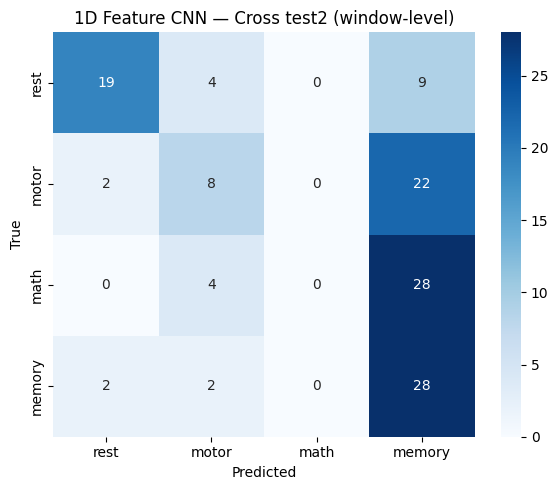

              precision    recall  f1-score   support

        rest       0.83      0.59      0.69        32
       motor       0.44      0.25      0.32        32
        math       0.00      0.00      0.00        32
      memory       0.32      0.88      0.47        32

    accuracy                           0.43       128
   macro avg       0.40      0.43      0.37       128
weighted avg       0.40      0.43      0.37       128

1D Feature CNN test3 window accuracy: 0.5312


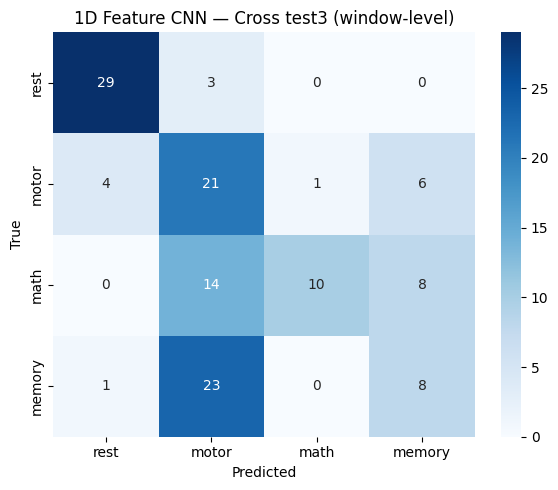

              precision    recall  f1-score   support

        rest       0.85      0.91      0.88        32
       motor       0.34      0.66      0.45        32
        math       0.91      0.31      0.47        32
      memory       0.36      0.25      0.30        32

    accuracy                           0.53       128
   macro avg       0.62      0.53      0.52       128
weighted avg       0.62      0.53      0.52       128



In [25]:
cross_results = {}

# primary CNN uses precomputed absolute bandpower for feature augmentation
bp_train_abs = np.load(os.path.join(BP_DIR, "X_cross_train_bp_abs.npy"))
bp_t1_abs = np.load(os.path.join(BP_DIR, "X_cross_test1_bp_abs.npy"))
bp_t2_abs = np.load(os.path.join(BP_DIR, "X_cross_test2_bp_abs.npy"))
bp_t3_abs = np.load(os.path.join(BP_DIR, "X_cross_test3_bp_abs.npy"))

X_train_1d = prepare_1d_feature_input(X_cross_train_w, bp_train_abs)
X_t1_1d = prepare_1d_feature_input(X_cross_test1_w, bp_t1_abs)
X_t2_1d = prepare_1d_feature_input(X_cross_test2_w, bp_t2_abs)
X_t3_1d = prepare_1d_feature_input(X_cross_test3_w, bp_t3_abs)

y_train_cat = keras.utils.to_categorical(y_cross_train_w, num_classes=4)
tr_idx, va_idx = grouped_split_indices(y_cross_train_w, cross_train_groups, test_size=0.2, seed=SEED)

X_train_split = X_train_1d[tr_idx]
X_val_split = X_train_1d[va_idx]
y_train_split = y_train_cat[tr_idx]
y_val_split = y_train_cat[va_idx]

cnn_1d_cross = build_1d_cnn(X_train_split.shape[1:], 4, dropout_rate=0.3, initial_filters=16, attention=False)

cnn_1d_cross.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_val_split, y_val_split),
    batch_size=16,
    epochs=40,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
    ],
    verbose=2,
)

cnn_split_acc = {}
for split_name, X_split, y_split in [
    ("test1", X_t1_1d, y_cross_test1_w),
    ("test2", X_t2_1d, y_cross_test2_w),
    ("test3", X_t3_1d, y_cross_test3_w),
]:
    y_pred = np.argmax(cnn_1d_cross.predict(X_split, verbose=0), axis=1)
    acc = accuracy_score(y_split, y_pred)
    cnn_split_acc[split_name] = float(acc)
    print(f"1D Feature CNN {split_name} window accuracy: {acc:.4f}")
    plot_cm_and_report(y_split, y_pred, f"1D Feature CNN — Cross {split_name} (window-level)")

cnn_split_acc["mean"] = float(np.mean([cnn_split_acc["test1"], cnn_split_acc["test2"], cnn_split_acc["test3"]]))
cross_results["1D Feature CNN"] = cnn_split_acc

## Alternative — EEGNet (Raw Windows)


Epoch   1/50 | val acc=0.2740
Epoch  10/50 | val acc=0.6731
Epoch  20/50 | val acc=0.7115
Early stopping at epoch 22 (best val acc=0.7644)
EEGNet (raw) test1 window accuracy: 0.5234


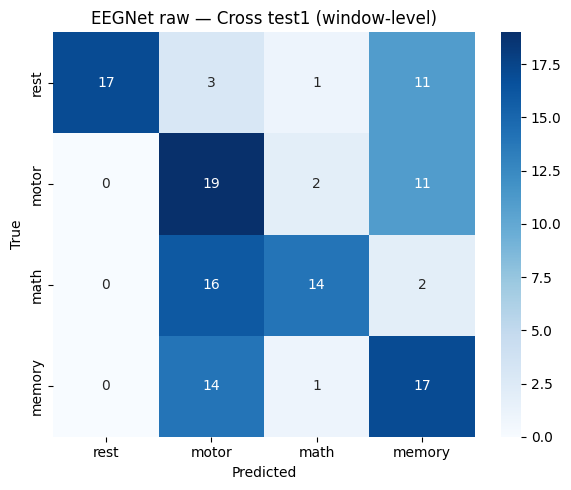

              precision    recall  f1-score   support

        rest       1.00      0.53      0.69        32
       motor       0.37      0.59      0.45        32
        math       0.78      0.44      0.56        32
      memory       0.41      0.53      0.47        32

    accuracy                           0.52       128
   macro avg       0.64      0.52      0.54       128
weighted avg       0.64      0.52      0.54       128

EEGNet (raw) test2 window accuracy: 0.4844


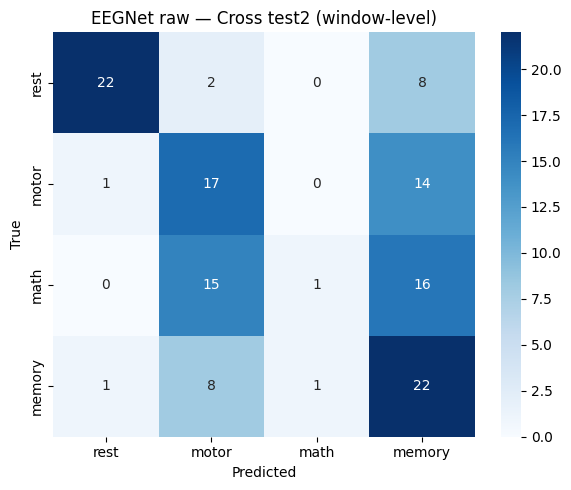

              precision    recall  f1-score   support

        rest       0.92      0.69      0.79        32
       motor       0.40      0.53      0.46        32
        math       0.50      0.03      0.06        32
      memory       0.37      0.69      0.48        32

    accuracy                           0.48       128
   macro avg       0.55      0.48      0.45       128
weighted avg       0.55      0.48      0.45       128

EEGNet (raw) test3 window accuracy: 0.5781


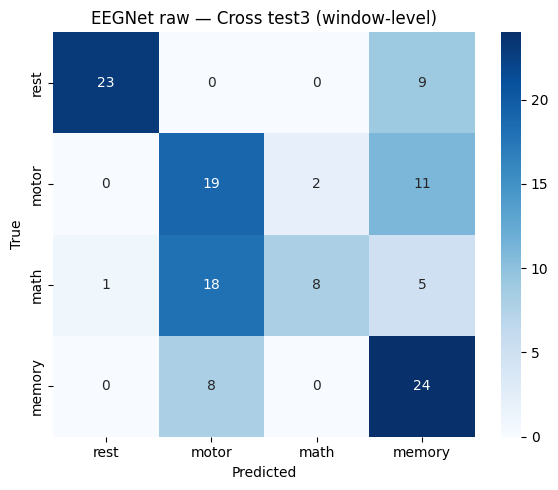

              precision    recall  f1-score   support

        rest       0.96      0.72      0.82        32
       motor       0.42      0.59      0.49        32
        math       0.80      0.25      0.38        32
      memory       0.49      0.75      0.59        32

    accuracy                           0.58       128
   macro avg       0.67      0.58      0.57       128
weighted avg       0.67      0.58      0.57       128



In [26]:
class EEGNet(nn.Module):
    def __init__(self, n_classes=4, n_channels=248, n_timesteps=500, F1=8, D=2, F2=16, kern_len=64, dropout=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kern_len), padding=(0, kern_len // 2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout),
        )
        self._flat_size = self._get_flat_size(n_channels, n_timesteps)
        self.classifier = nn.Linear(self._flat_size, n_classes)

    def _get_flat_size(self, n_channels, n_timesteps):
        with torch.no_grad():
            x = torch.zeros(1, 1, n_channels, n_timesteps)
            x = self.block1(x)
            x = self.block2(x)
            return x.numel()

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


def make_loader(X, y, batch_size=16, shuffle=True):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)


@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    preds, labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * len(yb)
        p = logits.argmax(1)
        correct += (p == yb).sum().item()
        preds.extend(p.cpu().numpy())
        labels.extend(yb.cpu().numpy())
    n = len(loader.dataset)
    return total_loss / n, correct / n, np.array(preds), np.array(labels)


def train_eegnet_raw(X_train, y_train, groups_local, epochs=50, batch_size=16, lr=1e-3, patience=10):
    train_idx, val_idx = grouped_split_indices(y_train, groups_local, test_size=0.2, seed=SEED)
    tr_loader = make_loader(X_train[train_idx], y_train[train_idx], batch_size=batch_size, shuffle=True)
    va_loader = make_loader(X_train[val_idx], y_train[val_idx], batch_size=batch_size, shuffle=False)

    model = EEGNet(n_channels=X_train.shape[1], n_timesteps=X_train.shape[2]).to(DEVICE)
    cls_w = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    cls_w_t = torch.tensor(cls_w, dtype=torch.float32, device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cls_w_t)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_acc = -1.0
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        va_loss, va_acc, _, _ = evaluate_loader(model, va_loader, criterion)
        scheduler.step(va_loss)

        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs} | val acc={va_acc:.4f}")

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best val acc={best_acc:.4f})")
            break

    model.load_state_dict(best_state)
    return model


eegnet_raw = train_eegnet_raw(X_cross_train_w, y_cross_train_w, cross_train_groups)
criterion = nn.CrossEntropyLoss()

raw_split_acc = {}
for split_name, X_split, y_split in [
    ("test1", X_cross_test1_w, y_cross_test1_w),
    ("test2", X_cross_test2_w, y_cross_test2_w),
    ("test3", X_cross_test3_w, y_cross_test3_w),
]:
    loader = make_loader(X_split, y_split, batch_size=32, shuffle=False)
    _, acc, preds, labels = evaluate_loader(eegnet_raw, loader, criterion)
    raw_split_acc[split_name] = float(acc)
    print(f"EEGNet (raw) {split_name} window accuracy: {acc:.4f}")
    plot_cm_and_report(labels, preds, f"EEGNet raw — Cross {split_name} (window-level)")

raw_split_acc["mean"] = float(np.mean([raw_split_acc["test1"], raw_split_acc["test2"], raw_split_acc["test3"]]))
cross_results["EEGNet (raw)"] = raw_split_acc

## Alternative — EEGNet (Bandpower Windows)


Epoch   1/40 | val acc=0.2452
Epoch  20/40 | val acc=0.9279
Epoch  40/40 | val acc=0.9375
EEGNet (bandpower) test1 window accuracy: 0.4531


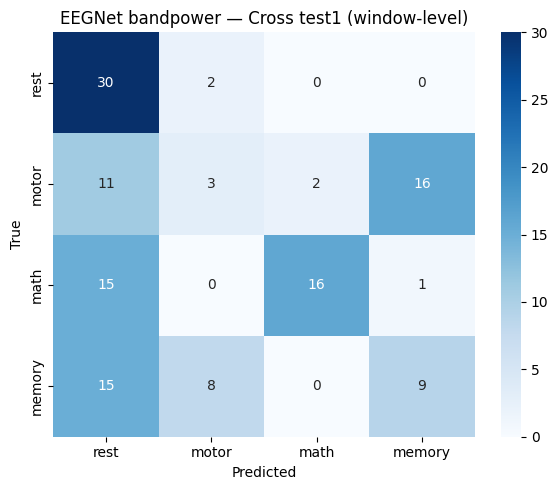

              precision    recall  f1-score   support

        rest       0.42      0.94      0.58        32
       motor       0.23      0.09      0.13        32
        math       0.89      0.50      0.64        32
      memory       0.35      0.28      0.31        32

    accuracy                           0.45       128
   macro avg       0.47      0.45      0.42       128
weighted avg       0.47      0.45      0.42       128

EEGNet (bandpower) test2 window accuracy: 0.3281


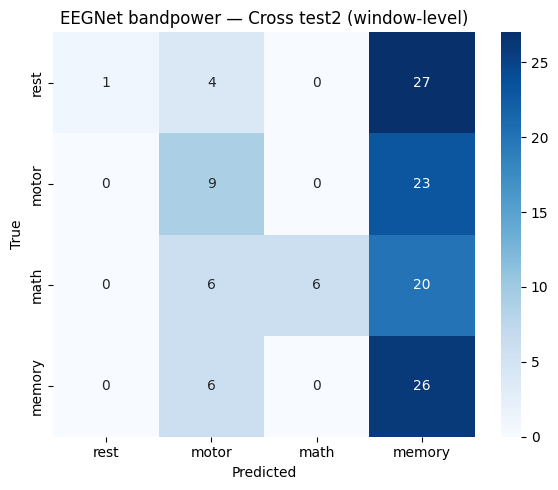

              precision    recall  f1-score   support

        rest       1.00      0.03      0.06        32
       motor       0.36      0.28      0.32        32
        math       1.00      0.19      0.32        32
      memory       0.27      0.81      0.41        32

    accuracy                           0.33       128
   macro avg       0.66      0.33      0.27       128
weighted avg       0.66      0.33      0.27       128

EEGNet (bandpower) test3 window accuracy: 0.3672


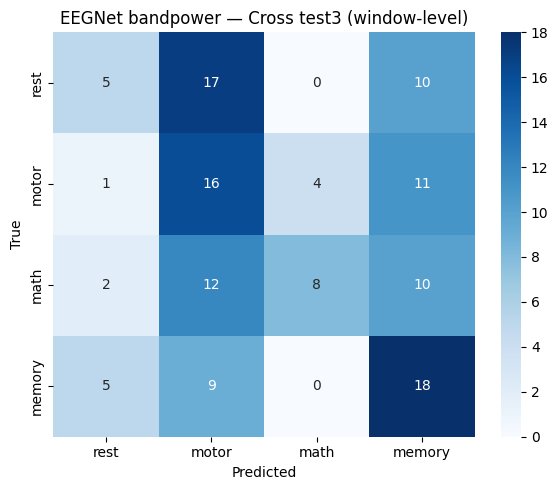

              precision    recall  f1-score   support

        rest       0.38      0.16      0.22        32
       motor       0.30      0.50      0.37        32
        math       0.67      0.25      0.36        32
      memory       0.37      0.56      0.44        32

    accuracy                           0.37       128
   macro avg       0.43      0.37      0.35       128
weighted avg       0.43      0.37      0.35       128



In [27]:
# EEGNet on bandpower windows
X_cross_bp_train = np.load(os.path.join(BP_DIR, "X_cross_train_bp_rel.npy"))
y_cross_bp_train = np.load(os.path.join(BP_DIR, "y_cross_train_w.npy"))
X_cross_bp_t1 = np.load(os.path.join(BP_DIR, "X_cross_test1_bp_rel.npy"))
y_cross_bp_t1 = np.load(os.path.join(BP_DIR, "y_cross_test1_w.npy"))
X_cross_bp_t2 = np.load(os.path.join(BP_DIR, "X_cross_test2_bp_rel.npy"))
y_cross_bp_t2 = np.load(os.path.join(BP_DIR, "y_cross_test2_w.npy"))
X_cross_bp_t3 = np.load(os.path.join(BP_DIR, "X_cross_test3_bp_rel.npy"))
y_cross_bp_t3 = np.load(os.path.join(BP_DIR, "y_cross_test3_w.npy"))


class EEGNetBandpower(nn.Module):
    def __init__(self, n_classes=4, n_channels=248, n_timesteps=5, F1=8, D=2, F2=16, kern_len=3, dropout=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kern_len), padding=(0, kern_len // 2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 2)),
            nn.Dropout(dropout),
        )
        sep_kern = min(3, max(1, n_timesteps // 2))
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, sep_kern), padding=(0, sep_kern // 2), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(F2, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


def train_eegnet_bp(X_train, y_train, groups_local, epochs=40, batch_size=32, lr=1e-3, patience=8):
    train_idx, val_idx = grouped_split_indices(y_train, groups_local, test_size=0.2, seed=SEED)
    tr_loader = make_loader(X_train[train_idx], y_train[train_idx], batch_size=batch_size, shuffle=True)
    va_loader = make_loader(X_train[val_idx], y_train[val_idx], batch_size=batch_size, shuffle=False)

    model = EEGNetBandpower(n_channels=X_train.shape[1], n_timesteps=X_train.shape[2], kern_len=min(3, X_train.shape[2]), dropout=0.5).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc = -1.0
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()

        _, va_acc, _, _ = evaluate_loader(model, va_loader, criterion)
        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs} | val acc={va_acc:.4f}")

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best val acc={best_acc:.4f})")
            break

    model.load_state_dict(best_state)
    return model


cross_bp_groups = make_window_groups(len(y_cross_bp_train), len(y_cross_train_rec))
eegnet_bp = train_eegnet_bp(X_cross_bp_train, y_cross_bp_train, cross_bp_groups)
criterion = nn.CrossEntropyLoss()

bp_split_acc = {}
for split_name, X_split, y_split in [
    ("test1", X_cross_bp_t1, y_cross_bp_t1),
    ("test2", X_cross_bp_t2, y_cross_bp_t2),
    ("test3", X_cross_bp_t3, y_cross_bp_t3),
]:
    loader = make_loader(X_split, y_split, batch_size=32, shuffle=False)
    _, acc, preds, labels = evaluate_loader(eegnet_bp, loader, criterion)
    bp_split_acc[split_name] = float(acc)
    print(f"EEGNet (bandpower) {split_name} window accuracy: {acc:.4f}")
    plot_cm_and_report(labels, preds, f"EEGNet bandpower — Cross {split_name} (window-level)")

bp_split_acc["mean"] = float(np.mean([bp_split_acc["test1"], bp_split_acc["test2"], bp_split_acc["test3"]]))
cross_results["EEGNet (bandpower)"] = bp_split_acc

## Alternative — GAT and CNN-GAT


In [28]:
# Cross GAT + CNN-GAT

def build_structural_adjacency(n_sensors=248, sigma=20.0):
    idx = np.arange(n_sensors, dtype=np.float32)
    dist = np.abs(idx[:, None] - idx[None, :])
    A = np.exp(-(dist ** 2) / (2 * sigma ** 2))
    np.fill_diagonal(A, 1.0)
    degree = A.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-8))
    return (D_inv_sqrt @ A @ D_inv_sqrt).astype("float32")


def build_functional_adjacency(X_train):
    X_flat = X_train.transpose(1, 0, 2).reshape(X_train.shape[1], -1)
    corr = np.corrcoef(X_flat)
    corr = np.nan_to_num(corr)
    corr = np.clip(corr, 0, 1)
    np.fill_diagonal(corr, 1.0)
    degree = corr.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-8))
    return (D_inv_sqrt @ corr @ D_inv_sqrt).astype("float32")


def extract_relative_band_power(X, fs=254.0):
    bands = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
        "gamma": (30, 60),
    }
    n_samples, n_sensors, n_times = X.shape
    nperseg = min(256, n_times // 2)
    bp = np.zeros((n_samples, n_sensors, len(bands)), dtype="float32")
    for s in range(n_samples):
        for ch in range(n_sensors):
            freqs, psd = welch(X[s, ch], fs=fs, nperseg=nperseg)
            total = np.trapezoid(psd, freqs) + 1e-12
            for b_idx, (f_lo, f_hi) in enumerate(bands.values()):
                mask = (freqs >= f_lo) & (freqs <= f_hi)
                band = np.trapezoid(psd[mask], freqs[mask]) if mask.sum() > 1 else 0.0
                bp[s, ch, b_idx] = band / total
    return bp


class GATLayer(nn.Module):
    def __init__(self, in_features, out_features, dropout=0.3):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)
        self.a_src = nn.Linear(out_features, 1, bias=False)
        self.a_dst = nn.Linear(out_features, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.leaky_relu = nn.LeakyReLU(0.2)

    def forward(self, H, A):
        B, N, _ = H.shape
        Wh = self.W(H)
        e_src = self.a_src(Wh)
        e_dst = self.a_dst(Wh)
        e = self.leaky_relu(e_src + e_dst.transpose(1, 2))
        mask = (A <= 0).unsqueeze(0).expand(B, -1, -1)
        e = e.masked_fill(mask, float("-inf"))
        alpha = self.dropout(torch.softmax(e, dim=-1))
        return F.elu(torch.bmm(alpha, Wh))


class MEG_GAT(nn.Module):
    def __init__(self, temporal_features=32, n_bands=5, gat_hidden=16, n_classes=4, dropout=0.3):
        super().__init__()
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=25, stride=5),
            nn.ReLU(),
            nn.Conv1d(8, temporal_features, kernel_size=10, stride=5),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.bn_temporal = nn.BatchNorm1d(temporal_features)
        self.gat1 = GATLayer(temporal_features + n_bands, gat_hidden, dropout)
        self.bn1 = nn.BatchNorm1d(gat_hidden)
        self.gat2 = GATLayer(gat_hidden, gat_hidden, dropout)
        self.bn2 = nn.BatchNorm1d(gat_hidden)
        self.classifier = nn.Linear(gat_hidden, n_classes)

    def forward(self, X, A_dist, A_corr, BP):
        B, N, T = X.shape
        X = X.reshape(B * N, 1, T)
        X = self.temporal_conv(X).squeeze(-1)
        X = self.bn_temporal(X)
        X = X.reshape(B, N, -1)
        X = torch.cat([X, BP], dim=-1)
        X = self.gat1(X, A_dist)
        X = self.bn1(X.reshape(B * N, -1)).reshape(B, N, -1)
        X = self.gat2(X, A_corr)
        X = self.bn2(X.reshape(B * N, -1)).reshape(B, N, -1)
        return self.classifier(X.mean(dim=1))


class TemporalAttention1D(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.attn = nn.Linear(in_features, 1)

    def forward(self, x):
        weights = torch.softmax(torch.tanh(self.attn(x)), dim=1)
        return x * weights


class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, ratio=8):
        super().__init__()
        self.fc1 = nn.Linear(channels, max(1, channels // ratio))
        self.fc2 = nn.Linear(max(1, channels // ratio), channels)

    def forward(self, x):
        se = x.mean(dim=1)
        se = F.relu(self.fc1(se))
        se = torch.sigmoid(self.fc2(se))
        return x * se.unsqueeze(1)


class JulianCNNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dropout=0.3):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size // 2)
        self.bn = nn.BatchNorm1d(out_ch)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(dropout)
        self.t_attn = TemporalAttention1D(out_ch)
        self.se = SqueezeExcite1D(out_ch)

    def forward(self, x):
        x = F.relu(self.bn(self.conv(x)))
        x = self.pool(x)
        x = self.dropout(x)
        x = x.transpose(1, 2)
        x = self.t_attn(x)
        x = self.se(x)
        return x.transpose(1, 2)


class JulianTemporalExtractor(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.block1 = JulianCNNBlock(1, 16, 7, dropout)
        self.block2 = JulianCNNBlock(16, 32, 5, dropout)
        self.block3 = JulianCNNBlock(32, 64, 3, dropout)
        self.gap = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.gap(x).squeeze(-1)


class CNN_GAT(nn.Module):
    def __init__(self, n_bands=5, gat_hidden=32, n_classes=4, dropout=0.3):
        super().__init__()
        self.extractor = JulianTemporalExtractor(dropout=dropout)
        self.bn_temporal = nn.BatchNorm1d(64)
        self.gat1 = GATLayer(64 + n_bands, gat_hidden, dropout)
        self.ln1 = nn.LayerNorm(gat_hidden)
        self.gat2 = GATLayer(gat_hidden, gat_hidden, dropout)
        self.ln2 = nn.LayerNorm(gat_hidden)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(gat_hidden, n_classes)

    def forward(self, X, A, BP):
        B, N, T = X.shape
        X = X.reshape(B * N, 1, T)
        X = self.extractor(X)
        X = self.bn_temporal(X)
        X = X.reshape(B, N, -1)
        X = torch.cat([X, BP], dim=-1)
        X = self.ln1(self.gat1(X, A))
        X = self.ln2(self.gat2(X, A))
        return self.classifier(self.dropout(X.mean(dim=1)))


def train_eval_cross_gat_like(model_name, model_ctor, use_two_adj=False, epochs=40):
    X_train = X_cross_train_w
    y_train = y_cross_train_w
    groups = cross_train_groups

    BP_train = extract_relative_band_power(X_train) if use_two_adj else np.load(os.path.join(BP_DIR, "X_cross_train_bp_abs.npy"))

    tr_idx, va_idx = grouped_split_indices(y_train, groups, test_size=0.2, seed=SEED)

    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_t = torch.tensor(y_train, dtype=torch.long)
    BP_t = torch.tensor(BP_train, dtype=torch.float32)

    ds_tr = TensorDataset(X_t[tr_idx], BP_t[tr_idx], y_t[tr_idx])
    ds_va = TensorDataset(X_t[va_idx], BP_t[va_idx], y_t[va_idx])
    dl_tr = DataLoader(ds_tr, batch_size=32, shuffle=True)
    dl_va = DataLoader(ds_va, batch_size=32, shuffle=False)

    A_dist = torch.tensor(build_structural_adjacency(X_train.shape[1]), dtype=torch.float32, device=DEVICE)
    A_corr = torch.tensor(build_functional_adjacency(X_train), dtype=torch.float32, device=DEVICE) if use_two_adj else None

    model = model_ctor().to(DEVICE)
    cls_w = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    cls_w_t = torch.tensor(cls_w, dtype=torch.float32, device=DEVICE)
    crit = nn.CrossEntropyLoss(weight=cls_w_t)
    opt = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=5e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=5, min_lr=1e-5)

    best_state = None
    best_val = -1.0
    no_imp = 0
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, bpb, yb in dl_tr:
            xb, bpb, yb = xb.to(DEVICE), bpb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out = model(xb, A_dist, A_corr, bpb) if use_two_adj else model(xb, A_dist, bpb)
            loss = crit(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            ok = 0
            tot = 0
            for xb, bpb, yb in dl_va:
                xb, bpb, yb = xb.to(DEVICE), bpb.to(DEVICE), yb.to(DEVICE)
                out = model(xb, A_dist, A_corr, bpb) if use_two_adj else model(xb, A_dist, bpb)
                p = out.argmax(1)
                ok += (p == yb).sum().item()
                tot += len(yb)
            va = ok / max(1, tot)

        sch.step(va)
        if va > best_val:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"{model_name} epoch {epoch}/{epochs} val acc={va:.4f}")
        if no_imp >= 12:
            break

    model.load_state_dict(best_state)
    split_metrics = {}
    for split_name, X_split, y_split in [
        ("test1", X_cross_test1_w, y_cross_test1_w),
        ("test2", X_cross_test2_w, y_cross_test2_w),
        ("test3", X_cross_test3_w, y_cross_test3_w),
    ]:
        BP_split = extract_relative_band_power(X_split) if use_two_adj else np.load(os.path.join(BP_DIR, f"X_cross_{split_name}_bp_abs.npy"))
        Xs = torch.tensor(X_split, dtype=torch.float32, device=DEVICE)
        BPs = torch.tensor(BP_split, dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            out = model(Xs, A_dist, A_corr, BPs) if use_two_adj else model(Xs, A_dist, BPs)
            pred = out.argmax(1).cpu().numpy()
        acc = accuracy_score(y_split, pred)
        split_metrics[split_name] = float(acc)
        print(f"{model_name} {split_name} window accuracy: {acc:.4f}")

    split_metrics["mean"] = float(np.mean([split_metrics["test1"], split_metrics["test2"], split_metrics["test3"]]))
    return split_metrics


cross_results["GAT"] = train_eval_cross_gat_like("GAT", lambda: MEG_GAT(), use_two_adj=True, epochs=40)
cross_results["CNN-GAT"] = train_eval_cross_gat_like("CNN-GAT", lambda: CNN_GAT(), use_two_adj=False, epochs=40)

GAT epoch 1/40 val acc=0.3077
GAT epoch 10/40 val acc=0.5433
GAT epoch 20/40 val acc=0.6154
GAT epoch 30/40 val acc=0.5865
GAT test1 window accuracy: 0.3906
GAT test2 window accuracy: 0.3750
GAT test3 window accuracy: 0.2656
CNN-GAT epoch 1/40 val acc=0.3798
CNN-GAT epoch 10/40 val acc=0.2212
CNN-GAT test1 window accuracy: 0.3359
CNN-GAT test2 window accuracy: 0.3281
CNN-GAT test3 window accuracy: 0.3984


## Save Cross Results


In [29]:
out_path = os.path.join(RESULTS_DIR, "cross_results.json")
with open(out_path, "w") as f:
    json.dump(cross_results, f, indent=2)

print("Saved:", out_path)
print(json.dumps(cross_results, indent=2))

Saved: results/cross_results.json
{
  "1D Feature CNN": {
    "test1": 0.625,
    "test2": 0.4296875,
    "test3": 0.53125,
    "mean": 0.5286458333333334
  },
  "EEGNet (raw)": {
    "test1": 0.5234375,
    "test2": 0.484375,
    "test3": 0.578125,
    "mean": 0.5286458333333334
  },
  "EEGNet (bandpower)": {
    "test1": 0.453125,
    "test2": 0.328125,
    "test3": 0.3671875,
    "mean": 0.3828125
  },
  "GAT": {
    "test1": 0.390625,
    "test2": 0.375,
    "test3": 0.265625,
    "mean": 0.34375
  },
  "CNN-GAT": {
    "test1": 0.3359375,
    "test2": 0.328125,
    "test3": 0.3984375,
    "mean": 0.3541666666666667
  }
}
